Processing:  20220723/pass_123_c_191422_ffc/frame_c301_20220723_191357_sky.png
Pass number:  ['123', 'c']
Aircraft not level
-35.50053
-35.50053
Distance to cloud start:  15637.171165199377 m
Distance to cloud end:  4004.299741127167 m
Distance to cloud mid:  9820.735453163272 m
Using Distance to cloud mid:  9820.735453163272
No contours intersect within the search range of 380 pixels from x=380
Using dummy value for y y=[432]
Pixel height y coord:  432
Pixel height above center:  -144.0
-1424.1774523013985
x1:  483.0053226465202
the estimated cloud top height is:  4315.1608781576215
the start pass height was:  5138.204
the end pass height was:  5141.4424
pass number:  ['123', 'c']
Processing:  20220723/pass_123_c_191422_ffc/frame_c301_20220723_191418_sky.png
Pass number:  ['123', 'c']
Aircraft was not level
31.22437
Distance to cloud start:  17125.865411608334 m
Distance to cloud end:  1034.4970958166032 m
Distance to cloud mid:  9080.181253712468 m
Using Distance to cloud mid:  9080.

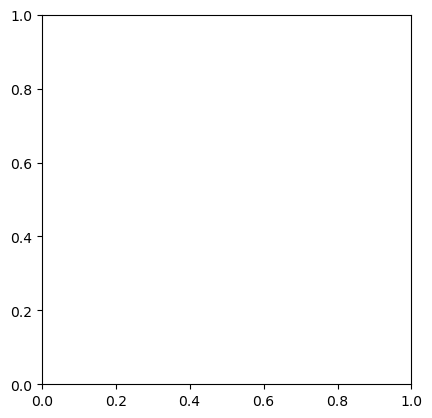

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import math
from datetime import datetime
from PIL import Image
from skimage import color
from skimage import io
import cv2
import height_calculator as hc
import glob
import os
import pandas as pd
from datetime import timedelta


ffc=True
rfc=False
# override the pixel height
pixel_height_override = False
yo = 130
# override the distance to the cloud default is mid
distance_override=False
pass_portion = 0.8
# x target for the cloud edge default is mid frame
x_target = 380
# set the camera name this changes the edge detection settings, and pitch correction
if ffc:
    camera_name = 'ffc'
if rfc:
    camera_name = 'rfc'

# Get the list of files
file_name_list = glob.glob('20220723/pass_*_'+camera_name+'/*')
dataset = xr.open_dataset('core_faam_20220723_v005_r0_c301_1hz.nc')
cloud_passes = pd.read_csv('FAAM_cloudpass_info.csv')

# file manipulation functions
def extract_pass_number(file_name):
    filepath_parts = file_name.split('/')
    if len(filepath_parts[1].split('_'))>4:
        pass_number= filepath_parts[1].split('_')[1:3]
    else:
        pass_number= filepath_parts[1].split('_')[1]
    return pass_number

def extract_timestamp_from_filename(filepath):
    filepath_parts = filepath.split('/')
    filename_parts = filepath_parts[2].split('_')
    if len(filepath_parts[1].split('_'))>4:
        camera= filepath_parts[1].split('_')[4]
    else:
        camera= filepath_parts[1].split('_')[3]
    date = filename_parts[2]
    times = filename_parts[3]
    full_timestamp = pd.to_datetime(date+'_'+times, format="%Y%m%d_%H%M%S")
    return [camera, full_timestamp] 

# Define a function to find the closest roll_time and get the corresponding roll_angle
def get_closest_roll_angle(aircraft_df, frame_time):
    # Calculate the absolute difference between frame_time and all roll_times
    diffs = abs(aircraft_df['times'] - frame_time)
    # Find the index of the minimum difference
    min_diff_index = diffs.idxmin()
    # Return the corresponding roll_angle
    return aircraft_df.loc[min_diff_index]

def extract_variables(dataset):
    roll = dataset['ROLL_GIN']
    lat = dataset['LAT_GIN'].data[:]
    lon = dataset['LON_GIN'].data[:]
    pitch = dataset['PTCH_GIN'].data[:]
    alt = dataset['PALT_RVS'].data[:]
    veln = dataset['VELN_GIN'].data[:]
    vele = dataset['VELE_GIN'].data[:]
    roll_times = roll.Time
    roll_angle = roll.data[:]
    roll_times_pd = pd.to_datetime(roll_times.data)
    aircraft_df = pd.DataFrame({'times': roll_times_pd, 'lat': lat, 'lon' : lon, 'pitch' : pitch, 'alt': alt, 
                                'roll_angles': roll_angle, 'veln': veln, 'vele': vele})
    return aircraft_df

alphabet_to_numbers = {chr(i): i - 97 for i in range(97, 123)}
def extract_cloud_pass_info(cloud_passes, pass_number,subpass=None):
    
    pass_info = cloud_passes.loc[int(pass_number)-1]

    cloud_lat1 = pass_info['start_lat']
    cloud_lon1 = pass_info['start_lon']
    cloud_lat2 = pass_info['end_lat']
    cloud_lon2 = pass_info['end_lon']
    if subpass:
        number = alphabet_to_numbers.get(subpass, None) 
        start_datetime = pd.to_datetime(pass_info['start_datetime'])
        end_datetime = pd.to_datetime(pass_info['end_datetime'])
        starttimes = pass_info['passes_start_index']
        starttimes = starttimes.strip('[]')
        starttimes = starttimes.split()
        endtimes = pass_info['passes_end_index']
        endtimes = endtimes.strip('[]')
        endtimes = endtimes.split()
        starttime = start_datetime+timedelta(seconds=(int(starttimes[number])-int(pass_info['start_index'])))
        endtime = end_datetime+timedelta(seconds=(int(endtimes[number])-int(pass_info['end_index'])))
        start_time = starttime.to_pydatetime()
        end_time = endtime.to_pydatetime()
    else:
        start_time = datetime.strptime(pass_info['start_datetime'], '%Y-%m-%d %H:%M:%S')
        end_time = datetime.strptime(pass_info['end_datetime'], '%Y-%m-%d %H:%M:%S')
    return [cloud_lat1, cloud_lon1, cloud_lat2, cloud_lon2, start_time, end_time]

def haversine( lon1, lat1, lon2, lat2, alt):
    R = 6371e3 + alt # radius of Earth in metres
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = phi2-phi1
    
    lambda1 = math.radians(lon1)
    lambda2 = math.radians(lon2)
    dlambda = lambda2-lambda1

    a = math.sin(dphi/2) * math.sin(dphi/2) + math.cos(phi1) * math.cos(phi1) * math.sin(dlambda/2) * math.sin(dlambda/2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

    d = R * c
    
    return d

# Define the column names
columns = ['d1', 'd2', 'plane_height', 'pass_height', 'cloud_height1','cloud_height2', 'cloud above plane height1',
           'cloud above plane height2', 'roll', 'pitch', 'pixel height', 'x_target','pass_number', 'camera', 'timestamp']

# Create an empty DataFrame with the specified columns
df = pd.DataFrame(columns=columns)
i =0
for file_name in file_name_list:
    # Get the distance
    #extract info
    print('Processing: ', file_name)
    camera, timestamp = extract_timestamp_from_filename(file_name)
    pass_number = extract_pass_number(file_name)
    print('Pass number: ', pass_number)
    aircraft_df = extract_variables(dataset)
    aircraft_position = get_closest_roll_angle(aircraft_df, timestamp)
    if isinstance(pass_number, list):
        pass_info = extract_cloud_pass_info(cloud_passes, pass_number[0],subpass=pass_number[1])
    else:
        pass_info = extract_cloud_pass_info(cloud_passes, pass_number)
    pass_lat1, pass_lon1, pass_lat2, pass_lon2, start_time, end_time = pass_info
    # get mid pass time and thus the aircraft position at that time
    mid_pass_time = start_time + (end_time - start_time)/2
    aircraft_pass_position_start = get_closest_roll_angle(aircraft_df, start_time)
    aircraft_pass_position_end = get_closest_roll_angle(aircraft_df, end_time)

    # Check roll
    if abs(aircraft_position['roll_angles']) > 15:
        print('Aircraft not level')
        print(aircraft_position['roll_angles'])
        print(aircraft_position['roll_angles'])
    elif abs(aircraft_pass_position_start['roll_angles']) > 10:
        print('Aircraft was not level')
        print(aircraft_pass_position_start['roll_angles'])
    elif abs(aircraft_pass_position_end['roll_angles']) > 10:
        print('Aircraft was not level')
        print(aircraft_pass_position_end['roll_angles'])
            
    D1 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon1, 
                   pass_lat1, aircraft_pass_position_start['alt'])
    D2 = haversine(aircraft_position['lon'], aircraft_position['lat'], pass_lon2, 
                   pass_lat2, aircraft_pass_position_end['alt'])
    D = (D1 + D2)/2

    print('Distance to cloud start: ', D1, 'm')
    print('Distance to cloud end: ', D2, 'm')
    print('Distance to cloud mid: ', D, 'm')

    print('Using Distance to cloud mid: ', + D)
    
    if distance_override:
        D = (D1 + D2) * pass_portion
        print('Overriding distance to: ', D)
    if ffc:
        # Set Constants for edge detection:
        # How white vs grey (this might need to be set by trial and error)    
        WHITENESS_THRESHOLD = 200
        # line thickness of box
        THICKNESS = 10
        # The part of every photo is just ground set to 0 if whole photo is cloud
        NOTSKY = 325

        img = io.imread(file_name)
        img_grey = color.rgb2gray(img)
        img_grey = cv2.bilateralFilter(img, 18, 100, 100)
        mask = np.all(img > WHITENESS_THRESHOLD, axis=-1)
        img_grey[~mask] = 0
        cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (7, 7), 0)
        edges = cv2.Canny(cv_grey, 0, 120)
        edges[NOTSKY::,:]=0
        edges[:,0:20]=0
        edges[:,-15::]=0
        edges[0:20,:]=0
    if rfc:
        # Set Constants for edge detection:
        # How white vs grey (this might need to be set by trial and error)    
        WHITENESS_THRESHOLD = 200
        # line thickness of box
        THICKNESS = 10
        # The part of every photo is just ground set to 0 if whole photo is cloud
        NOTSKY = 325

        img = io.imread(file_name)
        img_grey = color.rgb2gray(img)
        img_grey = cv2.bilateralFilter(img, 9, 75, 75)
        mask = np.all(img > WHITENESS_THRESHOLD, axis=-1)
        img_grey[~mask] = 0
        cv_grey = cv2.GaussianBlur(img_grey.astype(np.uint8) * 255, (7, 7), 0)
        edges = cv2.Canny(cv_grey, 50, 250)
        edges[NOTSKY::,:]=0
        edges[:,0:20]=0
        edges[:,-15::]=0
        edges[0:20,:]

    # Find contours and sort by area
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, 
                                    cv2.CHAIN_APPROX_SIMPLE)

    # Draw the contours on the original image
    thickness = 8  # Adjust this value to control the thickness of the drawn contours
    edge_image = cv2.imread(file_name).copy()
    cv2.drawContours(edge_image, contours, -1, (0, 255, 0), thickness)
    cv2.imwrite('cloud_edge.png', edge_image)
    cloud_edge=Image.open('cloud_edge.png')

    x_target = 380
    found_points = []
    search_range = 380



    def find_intersection(x_target):
        for contour in contours:
            for point in contour:
                x, y = point[0]
                if x == x_target:
                    return (x, y)
        return None


    # Search for intersection
    for offset in range(search_range):
        # Check current x_target
        result = find_intersection(x_target)
        if result:
            found_points.append(result)
            break

        # Check x_target + offset
        result = find_intersection(x_target + offset)
        if result:
            found_points.append(result)
            x_target += offset
            break

        # Check x_target - offset
        result = find_intersection(x_target - offset)
        if result:
            found_points.append(result)
            x_target -= offset
            break

    if found_points:
        x, y = found_points[-1]
        print(f"Contour intersects x={x_target} at y={y}")
    else:
        print(f"No contours intersect within the search range of {search_range} pixels from x={x_target}")
        print('Using dummy value for y y=[432]')
        y=432


    
    print('Pixel height y coord: ', y)

    try:
        pixel_height = 576- y
    except TypeError:
        pixel_height = 576- y[-1]
    
    
    if pixel_height_override:
        pixel_height = 576-yo
        print('Overriding pixel height to: ', pixel_height)

    pixel_height_adj=pixel_height-576/2
    print('Pixel height above center: ', pixel_height_adj)

    if ffc:
        calculator1=hc.CloudHeightCalculator(pixel_height_adj,D1,aircraft_pass_position_start['pitch']-3)
        calculator2=hc.CloudHeightCalculator(pixel_height_adj,D2,aircraft_pass_position_end['pitch']-3)
    if rfc:
        calculator1=hc.CloudHeightCalculator(pixel_height_adj,D1,-aircraft_pass_position_start['pitch']+3)
        calculator2=hc.CloudHeightCalculator(pixel_height_adj,D2,-aircraft_pass_position_end['pitch']+3)
    height_corrected1 =calculator1.calculate_height()
    height_corrected2 =calculator2.calculate_height()
    print(height_corrected1)

    # correct height of center of frame 
    if ffc:
        x1=D1*math.tan(math.radians(aircraft_pass_position_start['pitch']-3))
        x2=D2*math.tan(math.radians(aircraft_pass_position_end['pitch']-3))
    if rfc:
        x1=D1*math.tan(math.radians(-aircraft_pass_position_start['pitch']+3))
        x2=D2*math.tan(math.radians(-aircraft_pass_position_end['pitch']+3))
    
    print('x1: ', x1)
    
    # cloud top height is height of cloud edge + aircraft height 
    # + height adjustment of the center of the frame
    if ffc:    
        cloud_top_height1 = height_corrected1 + aircraft_position['alt']+x1
        cloud_top_height2 = height_corrected2 + aircraft_position['alt']+x2
    if rfc: 
        cloud_top_height1 = height_corrected1 + aircraft_position['alt']+x1
        cloud_top_height2 = height_corrected2 + aircraft_position['alt']+x2

    print('the estimated cloud top height is: ', cloud_top_height1)
    print('the start pass height was: ', aircraft_pass_position_start['alt'])
    print('the end pass height was: ',  aircraft_pass_position_end['alt'])
    print('pass number: ', pass_number)

    
    pass_diff1=cloud_top_height1-aircraft_pass_position_start['alt']
    pass_diff2=cloud_top_height2-aircraft_pass_position_end['alt']
    img = io.imread(file_name)
    plt.imshow(img)
    try:
        plt.plot(x_target, 576-pixel_height, 'ro')

        # Add text at the red dot position
        plt.text(10, 576 - pixel_height+30, f'Distance: {int(D1)}m, Height: {int(cloud_top_height1)} m, Pass_height: {int(aircraft_pass_position_start["alt"])} m',
                color='k', fontsize=12, ha='left', va='bottom')
        plt.text(10, 576 - pixel_height-20, f'Distance: {int(D2)}m, Height: {int(cloud_top_height2)} m, Pass_height: {int(aircraft_pass_position_end["alt"])} m', 
                color='k', fontsize=12, ha='left', va='bottom')
        plt.text(x_target-120, 480, f'aircraft height: {int(aircraft_position['alt'])} m', 
                color='k', fontsize=12, ha='left', va='bottom')
        
        # Display the roll_angle
        plt.text(0.1, 0.5, f'{aircraft_position['roll_angles']:,.2f}',
                    color='red',
                    horizontalalignment='left',
                    verticalalignment='center',
                    transform = plt.gca().transAxes,alpha=0.4)
    except ValueError:
        print('skipping')
        continue
    # Calculate line coordinates for roll angle
    if camera == 'ffc':
        angle_rad = np.deg2rad(-aircraft_position['roll_angles'])
    else:
        angle_rad = np.deg2rad(aircraft_position['roll_angles'])
    line_length = img.shape[1] / 2
    x = [img.shape[1] / 2 - line_length * np.cos(angle_rad), img.shape[1] / 2 + line_length * np.cos(angle_rad)]
    y = [img.shape[0] / 2 - line_length * np.sin(angle_rad), img.shape[0] / 2 + line_length * np.sin(angle_rad)]

    # Plot line
    plt.plot(x, y, color='red',linestyle='dashed',alpha=0.3)
    if len(pass_number)==2:
        plt.title('Pass {}_{}_{}, Timestamp: {}.'.format(pass_number[0],pass_number[1],camera_name, timestamp)+'\n Estimated plane pass height between {}m  and {}m below cloud top'.format(int(pass_diff1),int(pass_diff2)), fontsize=20)
        os.makedirs('figures/pass_{}_{}_{}/'.format(pass_number[0],pass_number[1],camera_name), exist_ok=True)
        plt.savefig('figures/pass_{}_{}_{}/{}_{}.png'.format(pass_number[0],pass_number[1],
                                                    camera_name,file_name.split('/')[-1].split('.')[0],camera_name), bbox_inches='tight', pad_inches=0.5)
    else:
        
        plt.title('Pass {}_{}, Timestamp: {}.'.format(pass_number,camera_name, timestamp)+'\n Estimated plane pass height between  {}m  and {}m below cloud top'.format(int(pass_diff1),int(pass_diff2)), fontsize=20)
        os.makedirs('figures/pass_{}_{}/'.format(pass_number,camera_name), exist_ok=True)
        plt.savefig('figures/pass_{}_{}/{}_{}.png'.format(pass_number,
                                                    camera_name,file_name.split('/')[-1].split('.')[0],camera_name), bbox_inches='tight', pad_inches=0.5)
    plt.cla()
    
    df.at[i, 'd1'] = D1
    df.at[i, 'd2'] = D2
    df.at[i, 'plane_height'] = aircraft_position['alt']
    df.at[i, 'start_pass_height'] = aircraft_pass_position_start['alt']
    df.at[i, 'end_pass_height'] = aircraft_pass_position_end['alt']
    df.at[i, 'cloud_height1'] = cloud_top_height1
    df.at[i, 'cloud_height2'] = cloud_top_height2
    df.at[i, 'cloud_above_plane_height'] =  pass_diff1
    df.at[i, 'cloud_above_plane_height'] =  pass_diff2
    df.at[i, 'roll'] = aircraft_position['roll_angles']
    df.at[i, 'pitch'] = aircraft_position['pitch']    
    df.at[i, 'pixel_height'] = pixel_height
    df.at[i, 'x_target'] = x_target
    if len(pass_number)==2:
        df.at[i, 'pass_number'] = pass_number[0]+'_'+pass_number[1]
    else:
        df.at[i, 'pass_number'] = pass_number
    df.at[i, 'camera'] = camera
    df.at[i, 'timestamp'] = timestamp
    i=i+1

df.to_csv('cloud_heights_'+camera+'.csv')
